In [1]:
%pylab inline
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
from matplotlib import pyplot
import seaborn as sns
from scipy.stats import gaussian_kde
import plotting
from matplotlib.colors import ListedColormap

Populating the interactive namespace from numpy and matplotlib


In [2]:
import global_imports
c = global_imports._c
G = global_imports._G
Msun = global_imports._M_s
pi = global_imports._pi
rho_ns = global_imports._rhons

In [3]:
np.log10(2*rho_ns)

14.729155073184936

In [4]:
np.log10(1.5*rho_ns)

14.604216336576636

In [5]:
tmp_color = sns.cubehelix_palette(8, start=.5, rot=-.75, dark=0.2, light=.85)[0::3]
c_baryonic = tmp_color[:2]
c_DE = ['#E76F51', 'xkcd:tomato']
c_bADM = ['xkcd:violet', 'xkcd:violet']
c_fADM = ['xkcd:azure', 'xkcd:cobalt blue']

In [6]:
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text', usetex=True)



pyplot.rcParams['xtick.direction'] = 'in'
pyplot.rcParams['xtick.minor.visible'] = True
pyplot.rcParams['ytick.direction'] = 'in'
pyplot.rcParams['ytick.minor.visible'] = True
pyplot.rcParams['xtick.major.size'] = 5
pyplot.rcParams['ytick.major.size'] = 5
pyplot.rcParams['ytick.right'] = True
pyplot.rcParams['xtick.top'] = True

In [7]:
linestyle_tuple = [
     ('loosely dotted',        (0, (1, 10))),
     ('dotted',                (0, (1, 1))),
     ('densely dotted',        (0, (1, 1))),

     ('loosely dashed',        (0, (5, 10))),
     ('dashed',                (0, (5, 5))),
     ('densely dashed',        (0, (5, 1))),

     ('loosely dashdotted',    (0, (3, 10, 1, 10))),
     ('dashdotted',            (0, (3, 5, 1, 5))),
     ('densely dashdotted',    (0, (3, 1, 1, 1))),

     ('dashdotdotted',         (0, (3, 5, 1, 5, 1, 5))),
     ('loosely dashdotdotted', (0, (3, 10, 1, 10, 1, 10))),
     ('densely dashdotdotted', (0, (3, 1, 1, 1, 1, 1)))]

In [8]:
print(linestyle_tuple[11][1])

(0, (3, 1, 1, 1, 1, 1))


In [9]:
colors = numpy.array(["#c6878f", "#b79d94", "#969696", "#67697c", "#233b57", "#BCBEC7"])

In [10]:
def calc_bands(x, y):
    miny = numpy.zeros((len(y),3))
    maxy = numpy.zeros((len(y),3))
    
    for i in range(len(y)):
        z = y[i][y[i]>0.0]
        if len(z)<200:
            print('sample too small for %.2f' %x[i])
            continue
        kde = gaussian_kde(z)
        testz = numpy.linspace(min(z),max(z), 1000)
        pdf = kde.pdf(testz)
        array = pdf
        index_68 = numpy.where(numpy.cumsum(numpy.sort(array)[::-1]) < sum(array)*0.6827)[0]
        index_68 = numpy.argsort(array)[::-1][index_68]
        index_95 = numpy.where(numpy.cumsum(numpy.sort(array)[::-1]) < sum(array)*0.95)[0]
        index_95 = numpy.argsort(array)[::-1][index_95]
        miny[i] =  x[i], min(testz[index_68]), min(testz[index_95])
        maxy[i] =  x[i], max(testz[index_68]), max(testz[index_95])
        
    miny = miny[~numpy.all(miny == 0, axis=1)]
    maxy = maxy[~numpy.all(maxy == 0, axis=1)]
    return miny, maxy


In [11]:
energydensities = numpy.logspace(14.2, 16, 50)
#pressures_prior = numpy.load('FERMIONIC_REAL_DATA_PRIOR_Pressure_array.npy')
minpres_prior = np.load('DE/Dark_energy_prior_minpres_total.npy')
maxpres_prior = np.load('DE/Dark_energy_prior_maxpres_total.npy')


prior_contours = minpres_prior,maxpres_prior
#prior_contours = calc_bands(energydensities, pressures_prior)
print(numpy.shape(prior_contours))


minpres_posterior = numpy.load('DE/Dark_energy_posterior_minpres_total.npy')
maxpres_posterior = numpy.load('DE/Dark_energy_posterior_maxpres_total.npy')
posterior_contours = minpres_posterior,maxpres_posterior

print(numpy.shape(posterior_contours))



energydensities_b = np.logspace(14.2, 16, 250)
energydensities_dm = np.logspace(11, 18, 250)
energydensities_ADM = energydensities_b + energydensities_dm

Bosonic_minpres_posterior = numpy.load('BDM/Bosonic_posterior_minpres_total.npy')
Bosonic_maxpres_posterior = numpy.load('BDM/Bosonic_posterior_maxpres_total.npy')
Bosonic_posterior_contours = Bosonic_minpres_posterior,Bosonic_maxpres_posterior

# pressures = numpy.load('BDM/Bosonic_posterior_pressures.npy')
# Bosonic_posterior_contours = calc_bands(energydensities_ADM, pressures)

print(numpy.shape(Bosonic_posterior_contours))


Fermionic_minpres_posterior = numpy.load('FDM/Fermionic_posterior_minpres.npy')
Fermionic_maxpres_posterior = numpy.load('FDM/Fermionic_posterior_maxpres.npy')
Fermionic_posterior_contours = Fermionic_minpres_posterior,Fermionic_maxpres_posterior

(2, 26, 3)
(2, 33, 3)
(2, 164, 3)


pressures = numpy.load('POSTERIOR_BARYONIC_REAL_pressures.npy')
contours = calc_bands(energydensities, pressures)
contours_min = contours[0]
contours_max = contours[1]
minpres_ppNI = numpy.log10(contours_min)
maxpres_ppNI = numpy.log10(contours_max)

In [12]:
def mass_radius_posterior_plot(root_name_1,root_name_2,root_name_3, root_name_4,ax = None):
    scatter_1 = numpy.loadtxt(root_name_1 + 'MR_prpr.txt')
    # scatter_ADM = []
    # for i in range(len(pre_scatter_ADM)):
    #     if pre_scatter_ADM[i][1] >0. and pre_scatter_ADM[i][1] < 20.: #eliminating Halos (>0) and the few stars that were sampled of having radii larger than what NICER considers (>20)
    #         scatter_ADM.append([pre_scatter_ADM[i][0],pre_scatter_ADM[i][1]])
            
    # scatter_ADM = numpy.array(scatter_ADM)
    

    
    sns.kdeplot(x = scatter_1[:,1], y = scatter_1[:,0], gridsize=40, 
               fill=False, ax=ax, levels=[0.05,1.],bw_adjust = 1.5,
                alpha=1., colors = '#E76F51',linestyles = '-.',linewidths = 3.)

    
    scatter_2 = numpy.loadtxt(root_name_2 + 'MR_prpr.txt')
        # scatter_prior = []
        # for i in range(len(pre_scatter_prior)):
        #     if pre_scatter_prior[i][-1] ==0.: #eliminating any halos that might appear after resampling the central density
        #         scatter_prior.append(pre_scatter_prior[i]) 
            
        # scatter_prior = numpy.array(scatter_prior)


    
    sns.kdeplot(x = scatter_2[:,1], y = scatter_2[:,0], gridsize=40, 
                fill=False, ax=ax, levels=[0.05,1.],bw_adjust = 1.5,
                alpha=1., colors = 'xkcd:violet',linestyles = '--',linewidths = 3.)

    scatter_3= numpy.loadtxt(root_name_3 + 'MR_prpr.txt')

    
    sns.kdeplot(x = scatter_3[:,1], y = scatter_3[:,0], gridsize=40,bw_adjust = 1.5, 
                fill=True, ax=ax, levels=[0.05,0.32,1.],
                alpha=1., cmap=ListedColormap(sns.cubehelix_palette(8, start=.5, rot=-.75, dark=.2, light=.85)[0::3]))

    # if root_name_4 is not None:
    scatter_4 = numpy.loadtxt(root_name_4 + 'MR_prpr.txt')
    sns.kdeplot(x = scatter_4[:,1], y = scatter_4[:,0], gridsize=40, 
                fill=False, ax=ax, levels=[0.05,1.],bw_adjust = 1.5,
                alpha=1., colors = 'xkcd:azure',linestyles = 'dotted',linewidths = 3.)
        
    
    #custom_lines = [Line2D([0],[0],color='#E76F51', alpha=1.,linestyle = '-.',lw = 3.),mpatches.Patch(color=sns.cubehelix_palette(8, start=.5, rot=-.75, dark=.2, light=.85)[0::3][1])]
   # ax.legend(custom_lines, ['Including ADM','Neglecting ADM'],
                #loc='upper left', prop={'size': 16})
    #ax.set_xlim(9, 15)
    #ax.set_xticks([10,11,12,13,14,15])
    ax.set_ylim(1., 2.7)
    ax.set_yticks([1.,1.4,1.8,2.2,2.7])
    
    #ax.set_title('Mass-Radius Posteriors',font = 'serif',fontsize = 24)
    ax.minorticks_on()
    ax.tick_params(top=1,right=1, which='both', direction='in', labelsize=20)
    ax.set_xlabel(r'Radius [km]', fontsize=20)
    ax.set_ylabel(r'Mass [M$_{\odot}$]', fontsize=20)
    
    #figure.savefig('MRpost_real_data.png',bbox_inches='tight')



In [13]:
root_name_1 = 'DE/Dark_energy_posterior_'
root_name_2 = 'BDM/Bosonic_posterior_'
root_name_3 = 'B/Baryonic_posterior_'
root_name_4 = 'FDM/Fermionic_posterior_'

In [14]:
contours_min = numpy.load('B/Baryonic_posterior_minpres.npy')
contours_max = numpy.load('B/Baryonic_posterior_maxpres.npy')
minpres_ppNI = numpy.log10(contours_min)
maxpres_ppNI = numpy.log10(contours_max)

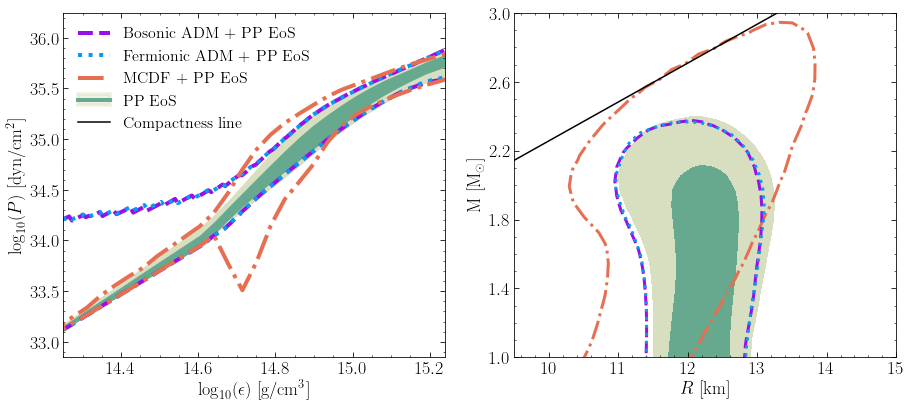

In [15]:
fig, ax = pyplot.subplots(nrows=1, ncols=2,figsize=(13,6))
fig.subplots_adjust(wspace=0.5, hspace=0)
my_fontsize=18
my_font = 'serif'
matplotlib.rc('font',family = my_font)
matplotlib.rcParams.update({'font.size': 18})

mass_radius_posterior_plot(root_name_1,root_name_2,root_name_3,root_name_4,ax = ax[1])


#maxpres_ppNI = numpy.log10(numpy.load(root_name_B + 'minpres.npy'))
#maxpres_ppNI = numpy.log10(numpy.load(root_name_B + 'maxpres.npy'))


posterior_contours_min = posterior_contours[0]
posterior_contours_max = posterior_contours[1]
minpres_posterior = numpy.log10(posterior_contours_min)
maxpres_posterior = numpy.log10(posterior_contours_max)

Bosonic_posterior_contours_min = Bosonic_posterior_contours[0]
Bosonic_posterior_contours_max = Bosonic_posterior_contours[1]
Bosonic_minpres_posterior = numpy.log10(Bosonic_posterior_contours_min)
Bosonic_maxpres_posterior = numpy.log10(Bosonic_posterior_contours_max)



Fermionic_posterior_contours_min = Fermionic_posterior_contours[0]
Fermionic_posterior_contours_max = Fermionic_posterior_contours[1]
Fermionic_minpres_posterior = numpy.log10(Fermionic_posterior_contours_min)
Fermionic_maxpres_posterior = numpy.log10(Fermionic_posterior_contours_max)

# prior_contours_min = prior_contours[0]
# prior_contours_max = prior_contours[1]
# minpres_prior = numpy.log10(prior_contours_min)
# maxpres_prior = numpy.log10(prior_contours_max)




# ax[0].plot(maxpres_prior[:,0], minpres_prior[:,2], c='black', linestyle='--', lw=2.75)
# ax[0].plot(maxpres_prior[:,0], maxpres_prior[:,2], c='black', linestyle='--', lw=2.75,label = 'Prior')

ax[0].plot(Bosonic_maxpres_posterior[:,0], Bosonic_minpres_posterior[:,2], c='xkcd:violet', linestyle='--', lw=4)
ax[0].plot(Bosonic_maxpres_posterior[:,0], Bosonic_maxpres_posterior[:,2], c='xkcd:violet', linestyle='--', lw=4)

ax[0].plot(Fermionic_maxpres_posterior[:,0], Fermionic_minpres_posterior[:,2], c='xkcd:azure', linestyle='dotted', lw=4)
ax[0].plot(Fermionic_maxpres_posterior[:,0], Fermionic_maxpres_posterior[:,2], c='xkcd:azure',
                                                        linestyle='dotted', lw=4)

ax[0].plot(maxpres_posterior[:,0], minpres_posterior[:,2], c='#E76F51', linestyle='-.', lw=4)
ax[0].plot(maxpres_posterior[:,0], maxpres_posterior[:,2], c='#E76F51', linestyle='-.', lw=4)
ax[0].fill_between(minpres_ppNI[:,0], minpres_ppNI[:,2], maxpres_ppNI[:,2], 
                       color=sns.cubehelix_palette(8, start=.5, rot=-.75, dark=.2, light=.85)[0], alpha=1)
ax[0].fill_between(minpres_ppNI[:,0], minpres_ppNI[:,1], maxpres_ppNI[:,1], 
                       color=sns.cubehelix_palette(8, start=.5, rot=-.75, dark=.2, light=.85)[3], 
                      alpha=1)
       

ax[0].set_ylabel(r'$\log_{10}(P)$ [dyn/cm$^2$]', size=my_fontsize,font = my_font)


masses = np.arange(1,3.2,.1)*Msun
rg3 = 3*masses*G/c**2/1e5
ax[1].plot(rg3,masses/Msun,color = 'xkcd:black')

line1 = plotting.custom_line(c_bADM[1], 'dashed', lw=4.)
line2 = plotting.custom_line(c_fADM[0], 'dotted', lw=4.)
line3 = plotting.custom_line(c_DE[0], '-.', lw=4.)
line4 = plotting.double_interval_legend(c_baryonic)
line5 = plotting.custom_line('xkcd:black', )
custom_lines = [line1, line2, line3, line4, line5]
ax[0].legend(custom_lines, ['Bosonic ADM + PP EoS', 'Fermionic ADM + PP EoS', 'MCDF + PP EoS','PP EoS', 'Compactness line'],loc = 'upper left',fontsize = 16, frameon=False)

ax[0].set_xlim(14.25, 15.24)
ax[0].set_xlabel(r'$\log_{10}(\epsilon)$ [g/cm$^3$]', fontsize=my_fontsize,font = my_font)
ax[0].set_xticks(numpy.arange(14.25, 15.24,.05),minor =True)
#ax[0].set_ylim(33,36)
#ax[0].set_yticks([33,33.5,34,34.5,35,35.5,36],minor =True)
ax[0].tick_params(top=1,right=1, which='both', direction='in', labelsize=my_fontsize)

ax[1].set_xlim(9.5, 15)
ax[1].set_xticks([10,11,12,13,14,15])
ax[1].set_ylim(1., 2.8)
ax[1].set_yticks([1.,1.4,1.8,2.2,2.6,3.0])
    
    #ax.set_title('Mass-Radius Posteriors',font = 'serif',fontsize = 24)
ax[1].minorticks_on()
ax[1].tick_params(top=1,right=1, which='both', direction='in', labelsize=my_fontsize)
ax[1].set_xlabel(r'$R$ [km]', fontsize=my_fontsize)
ax[1].set_ylabel(r'M [M$_{\odot}$]', fontsize=my_fontsize)
    

pyplot.tight_layout()
pyplot.show()
fig.savefig('plots/EoS_MR_posteriors_total.pdf',bbox_inches='tight')



In [16]:
energydensities = numpy.logspace(14.2, 16, 50)
#pressures_prior = numpy.load('FERMIONIC_REAL_DATA_PRIOR_Pressure_array.npy')
minpres_prior = np.load('DE/Dark_energy_prior_minpres_baryon.npy')
maxpres_prior = np.load('DE/Dark_energy_prior_maxpres_baryon.npy')


prior_contours = minpres_prior,maxpres_prior
#prior_contours = calc_bands(energydensities, pressures_prior)
print(numpy.shape(prior_contours))


minpres_posterior = numpy.load('DE/Dark_energy_posterior_minpres_baryon.npy')
maxpres_posterior = numpy.load('DE/Dark_energy_posterior_maxpres_baryon.npy')
posterior_contours = minpres_posterior,maxpres_posterior

print(numpy.shape(posterior_contours))

Bosonic_minpres_posterior = numpy.load('BDM/Bosonic_posterior_minpres_baryon.npy')
Bosonic_maxpres_posterior = numpy.load('BDM/Bosonic_posterior_maxpres_baryon.npy')
Bosonic_posterior_contours = Bosonic_minpres_posterior,Bosonic_maxpres_posterior


Fermionic_minpres_posterior = numpy.load('FDM/Fermionic_posterior_minpres_baryon.npy')
Fermionic_maxpres_posterior = numpy.load('FDM/Fermionic_posterior_maxpres_baryon.npy')
Fermionic_posterior_contours = Fermionic_minpres_posterior,Fermionic_maxpres_posterior

(2, 49, 3)
(2, 35, 3)


In [17]:
contours_min = numpy.load('B/Baryonic_posterior_minpres.npy')
contours_max = numpy.load('B/Baryonic_posterior_maxpres.npy')
minpres_ppNI = numpy.log10(contours_min)
maxpres_ppNI = numpy.log10(contours_max)

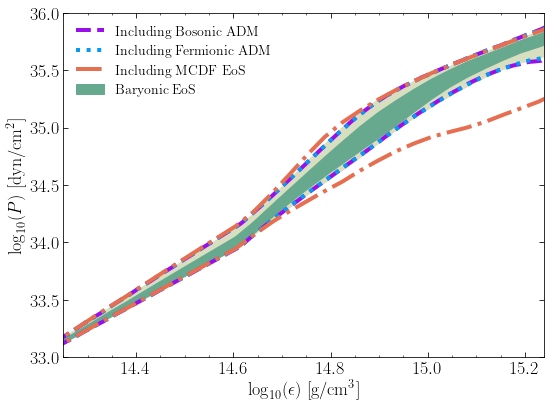

In [18]:
fig, ax = pyplot.subplots(nrows=1, ncols=1,figsize=(8,6))
my_fontsize=18
my_font = 'serif'
matplotlib.rc('font',family = my_font)
matplotlib.rcParams.update({'font.size': 18})




#maxpres_ppNI = numpy.log10(numpy.load(root_name_B + 'minpres.npy'))
#maxpres_ppNI = numpy.log10(numpy.load(root_name_B + 'maxpres.npy'))


posterior_contours_min = posterior_contours[0]
posterior_contours_max = posterior_contours[1]
minpres_posterior = numpy.log10(posterior_contours_min)
maxpres_posterior = numpy.log10(posterior_contours_max)


# prior_contours_min = prior_contours[0]
# prior_contours_max = prior_contours[1]
# minpres_prior = numpy.log10(prior_contours_min)
# maxpres_prior = numpy.log10(prior_contours_max)



Bosonic_posterior_contours_min = Bosonic_posterior_contours[0]
Bosonic_posterior_contours_max = Bosonic_posterior_contours[1]
Bosonic_minpres_posterior = numpy.log10(Bosonic_posterior_contours_min)
Bosonic_maxpres_posterior = numpy.log10(Bosonic_posterior_contours_max)


Fermionic_posterior_contours_min = Fermionic_posterior_contours[0]
Fermionic_posterior_contours_max = Fermionic_posterior_contours[1]
Fermionic_minpres_posterior = numpy.log10(Fermionic_posterior_contours_min)
Fermionic_maxpres_posterior = numpy.log10(Fermionic_posterior_contours_max)


# prior_contours_min = prior_contours[0]
# prior_contours_max = prior_contours[1]
# minpres_prior = numpy.log10(prior_contours_min)
# maxpres_prior = numpy.log10(prior_contours_max)




# ax[0].plot(maxpres_prior[:,0], minpres_prior[:,2], c='black', linestyle='--', lw=2.75)
# ax[0].plot(maxpres_prior[:,0], maxpres_prior[:,2], c='black', linestyle='--', lw=2.75,label = 'Prior')

ax.plot(Bosonic_maxpres_posterior[:,0], Bosonic_minpres_posterior[:,2], c='xkcd:violet', linestyle='--', lw=4)
ax.plot(Bosonic_maxpres_posterior[:,0], Bosonic_maxpres_posterior[:,2], c='xkcd:violet', linestyle='--', lw=4,label = 'Including Bosonic ADM')

ax.plot(Fermionic_maxpres_posterior[:,0], Fermionic_minpres_posterior[:,2], c='xkcd:azure', linestyle='dotted', lw=4)
ax.plot(Fermionic_maxpres_posterior[:,0], Fermionic_maxpres_posterior[:,2], c='xkcd:azure',
                                                        linestyle='dotted', lw=4,label = 'Including Fermionic ADM')

ax.plot(maxpres_posterior[:,0], minpres_posterior[:,2], c='#E76F51', linestyle='-.', lw=4)
ax.plot(maxpres_posterior[:,0], maxpres_posterior[:,2], c='#E76F51', linestyle='-.', lw=4,label = 'Including MCDF EoS')
ax.fill_between(minpres_ppNI[:,0], minpres_ppNI[:,2], maxpres_ppNI[:,2], 
                       color=sns.cubehelix_palette(8, start=.5, rot=-.75, dark=.2, light=.85)[0], alpha=1)
ax.fill_between(minpres_ppNI[:,0], minpres_ppNI[:,1], maxpres_ppNI[:,1], 
                       color=sns.cubehelix_palette(8, start=.5, rot=-.75, dark=.2, light=.85)[3], 
                      alpha=1,label = 'Baryonic EoS')
       

ax.set_ylabel(r'$\log_{10}(P)$ [dyn/cm$^2$]', size=my_fontsize,font = my_font)



ax.legend(loc = 'upper left',fontsize = 14, frameon=False)
ax.set_xlim(14.25, 15.24)
ax.set_xlabel(r'$\log_{10}(\epsilon)$ [g/cm$^3$]', fontsize=my_fontsize,font = my_font)
ax.set_xticks(numpy.arange(14.25, 15.24,.05),minor =True)
ax.set_ylim(33,36)
ax.set_yticks([33,33.5,34,34.5,35,35.5,36],minor =True)
ax.tick_params(top=1,right=1, which='both', direction='in', labelsize=my_fontsize)

    
    
pyplot.tight_layout()
pyplot.show()
fig.savefig('plots/EoS_posteriors_baryon.pdf',bbox_inches='tight')